# En este ejercicio se usa el análisis directo por frecuencias

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [8]:
np.random.seed(42)
n_jugadores = 100000

precio = np.random.choice(['Alto', 'Medio', 'Bajo'], n_jugadores, p=[0.3, 0.4, 0.3])
genero = np.random.choice(['Acción', 'Aventura', 'Estrategia', 'Otros'], n_jugadores)
criticas = np.random.choice(['Alta', 'Baja'], n_jugadores, p=[0.6, 0.4])
plataforma = np.random.choice(['Consola', 'PC'], n_jugadores, p=[0.5, 0.5])
amigos = np.random.choice(['Sí', 'No'], n_jugadores, p=[0.4, 0.6])

compra = np.zeros(n_jugadores)

In [9]:
for i in range(n_jugadores):
    prob = 0.1

    if precio[i] == 'Bajo':
        prob += 0.25
    elif precio[i] == 'Medio':
        prob += 0.15

    if criticas[i] == 'Alta':
        prob += 0.25

    if amigos[i] == 'Sí':
        prob += 0.20

    if genero[i] in ['Acción', 'Aventura']:
        prob += 0.10

    compra[i] = np.random.choice([1, 0], p=[min(prob, 0.95), 1 - min(prob, 0.95)])

In [10]:
data = pd.DataFrame({
    'Precio': precio,
    'Genero': genero,
    'Criticas': criticas,
    'Plataforma': plataforma,
    'Amigos': amigos,
    'Compra': compra
})

In [11]:
prob_compra = (data.groupby(['Precio', 'Criticas'])['Compra'].mean().reset_index())

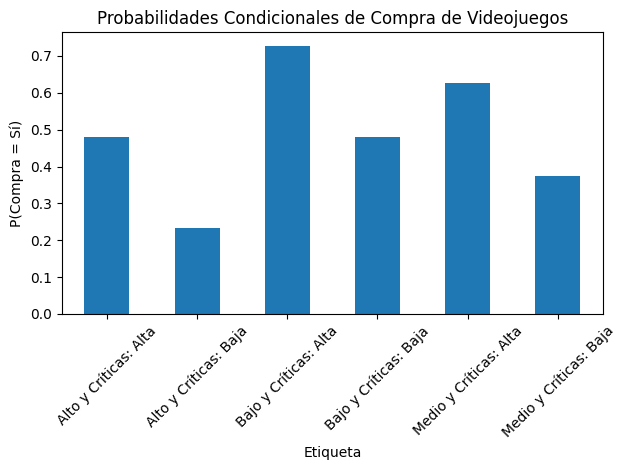

In [12]:
prob_compra['Etiqueta'] = (prob_compra['Precio'] + ' y Críticas: ' + prob_compra['Criticas'])

fig, ax = plt.subplots()

prob_compra.plot(
    kind='bar',
    x='Etiqueta',
    y='Compra',
    ax=ax,
    legend=False
)

ax.set_ylabel('P(Compra = Sí)')
ax.set_title('Probabilidades Condicionales de Compra de Videojuegos')

plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('probabilidades_condicionales_compra.png')
plt.show()